<a href="https://colab.research.google.com/github/Gyu-278/Linear_Regression_Exercise/blob/main/AI_Lab_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 Lab — Linear Regression: Normal Equation vs. Gradient Descent
**Artificial Intelligence for Civil and Environmental Engineering (AICEE)**

---

**Task.** Learn a model that predicts the compressive strength of concrete from its mix design, and train it in the two ways every machine-learning practitioner should know:

|  | **Normal equation** (closed form, one line) | **Gradient descent** (iterative) |
|---|---|---|
| **Single variable** | Example 1 | Example 2 |
| **Multiple variables** | Example 3 | Example 4 |

**By the end of this lab you will be able to**
1. Write the linear-regression hypothesis and cost function in vectorized form.
2. Train the model in **one line** with the Moore–Penrose pseudo-inverse, $\boldsymbol\theta = \mathbf X^{+}\mathbf y$, and explain why `pinv` is preferred over an explicit inverse.
3. Implement batch gradient descent from scratch, choose a learning rate, and explain why feature scaling matters.
4. Evaluate every model on held-out test data and decide which training method fits a given problem.

**How to use this notebook in Colab**
- `File → Save a copy in Drive`, then `Runtime → Run all` (CPU is enough; about one minute).
- Cells marked **✏️ Exercise** contain `TODO` items for you to complete.

## 0. Setup

In [1]:
!pip -q install ucimlrepo

In [2]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression          # used only as a sanity check
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
print(f"numpy {np.__version__} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}")

numpy 2.1.3 | pandas 2.2.3 | scikit-learn 1.6.1


---
## 1. Problem set-up and notation

We use the **UCI Concrete Compressive Strength** dataset: 1,030 mixes, 8 input features (kg/m³ of each component, plus age in days) and one target (strength in MPa).

**Notation (machine-learning convention)**

| Symbol | Meaning |
|---|---|
| $m$ | number of training examples |
| $n$ | number of input features |
| $\mathbf x^{(i)}\in\mathbb R^{n}$, $y^{(i)}$ | features and target of example $i$ |
| $\mathbf X\in\mathbb R^{m\times(n+1)}$ | design matrix: one row per example, first column all ones (bias $x_0=1$) |
| $\boldsymbol\theta\in\mathbb R^{n+1}$ | parameters: $\theta_0$ is the bias, $\theta_1,\dots,\theta_n$ are the weights |

**Hypothesis** (the model):

$$
h_{\boldsymbol\theta}(\mathbf x) = \theta_0 + \theta_1x_1 + \dots + \theta_nx_n = \boldsymbol\theta^\top\mathbf x
\qquad\Longrightarrow\qquad
\hat{\mathbf y} = \mathbf X\boldsymbol\theta \quad\text{(all examples at once)}
$$

**Cost function** (what training minimizes):

$$
J(\boldsymbol\theta) = \frac{1}{2m}\sum_{i=1}^{m}\big(h_{\boldsymbol\theta}(\mathbf x^{(i)})-y^{(i)}\big)^2
= \frac{1}{2m}\,\lVert \mathbf X\boldsymbol\theta-\mathbf y\rVert^2
$$

The factor $\tfrac12$ only makes the gradient cleaner; it does not change the minimizer.

**Two ways to find** $\boldsymbol\theta^* = \arg\min_{\boldsymbol\theta} J(\boldsymbol\theta)$:
- **Normal equation** — solve $\nabla J = \mathbf 0$ analytically, in one step.
- **Gradient descent** — start somewhere and walk downhill until $J$ stops decreasing.

**Generalization.** We train on 80 % of the data and report RMSE, MAE and $R^2$ on the remaining 20 % that the model never saw.

In [3]:
COLS = ["cement", "slag", "fly_ash", "water", "superplasticizer",
        "coarse_agg", "fine_agg", "age", "strength"]

def make_surrogate(n=1030, seed=SEED):
    # Offline fallback with realistic ranges (Abrams' law + ACI 209 strength gain).
    r = np.random.default_rng(seed)
    cement = r.uniform(102, 540, n)
    slag   = np.where(r.random(n) < 0.55, r.uniform(0, 359, n), 0.0)
    fly    = np.where(r.random(n) < 0.45, r.uniform(0, 200, n), 0.0)
    water  = r.uniform(122, 247, n)
    sp     = np.where(r.random(n) < 0.60, r.uniform(0, 32, n), 0.0)
    coarse = r.uniform(801, 1145, n)
    fine   = np.clip(2350 - cement - slag - fly - water - sp - coarse + r.normal(0, 40, n), 594, 993)
    age    = r.choice([1, 3, 7, 14, 28, 56, 90, 100, 180, 270, 365], n,
                      p=[.02, .13, .12, .06, .41, .09, .08, .04, .03, .01, .01])
    w_b = water / (cement + 0.6 * slag + 0.3 * fly)
    f28 = 96.5 / 5.0 ** w_b * (1 + 0.004 * sp)
    strength = np.clip(f28 * age / (4.0 + 0.85 * age) + r.normal(0, 5.0, n), 2.3, 82.6)
    return pd.DataFrame(np.column_stack([cement, slag, fly, water, sp, coarse, fine, age, strength]),
                        columns=COLS)

def load_concrete():
    try:
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=165)
        df = pd.concat([ds.data.features, ds.data.targets], axis=1)
        df.columns = COLS
        return df, "UCI (ucimlrepo)"
    except Exception:
        try:
            df = pd.read_excel("https://archive.ics.uci.edu/ml/machine-learning-databases/"
                               "concrete/compressive/Concrete_Data.xls")
            df.columns = COLS
            return df, "UCI (direct .xls)"
        except Exception:
            return make_surrogate(), "SURROGATE (offline fallback — do not report these numbers)"

df, source = load_concrete()
print(f"Data source: {source}   shape: {df.shape}")

train_df, test_df = train_test_split(df, test_size=0.2, random_state=SEED)
y_tr = train_df["strength"].to_numpy()
y_te = test_df["strength"].to_numpy()
print(f"train: {len(train_df)} examples   test: {len(test_df)} examples")
df.head()

Data source: UCI (ucimlrepo)   shape: (1030, 9)
train: 824 examples   test: 206 examples


,cement,slag,fly_ash,water,superplasticizer,coarse_agg,fine_agg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [4]:
# Helper functions shared by all four examples
def add_bias(X):
    # Prepend the column x0 = 1 so that θ0 acts as the bias term.
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    return np.column_stack([np.ones(len(X)), X])

def compute_cost(X, y, theta):
    # J(θ) = 1/(2m) · ||Xθ − y||²
    m = len(y)
    err = X @ theta - y
    return (err @ err) / (2 * m)

def scores(y_true, y_pred):
    return {"RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAE": mean_absolute_error(y_true, y_pred),
            "R2": r2_score(y_true, y_pred)}

results = []          # collects the test scores of every example
def record(name, y_pred_train, y_pred_test, **extra):
    row = {"model": name}
    row.update({f"train {k}": v for k, v in scores(y_tr, y_pred_train).items()})
    row.update({f"test {k}": v for k, v in scores(y_te, y_pred_test).items()})
    row.update(extra)
    results.append(row)
    return pd.DataFrame([row]).round(3)

---
## 2. Example 1 — Single variable, normal equation with the pseudo-inverse

### From the cost function to a one-line solution
The gradient of the cost function is

$$
\nabla_{\boldsymbol\theta} J = \frac{1}{m}\mathbf X^\top(\mathbf X\boldsymbol\theta-\mathbf y).
$$

At the minimum the gradient is zero, which gives the **normal equation**

$$
\mathbf X^\top\mathbf X\,\boldsymbol\theta = \mathbf X^\top\mathbf y
\quad\Longrightarrow\quad
\boldsymbol\theta = \underbrace{(\mathbf X^\top\mathbf X)^{-1}\mathbf X^\top}_{\mathbf X^{+}}\,\mathbf y .
$$

The matrix $\mathbf X^{+}$ is the **Moore–Penrose pseudo-inverse** of $\mathbf X$. It has shape $(n+1)\times m$ and maps targets directly to parameters.

### Why `pinv` instead of `inv`?
NumPy computes $\mathbf X^{+}$ from the singular value decomposition $\mathbf X=\mathbf U\boldsymbol\Sigma\mathbf V^\top$:

$$
\mathbf X^{+} = \mathbf V\boldsymbol\Sigma^{+}\mathbf U^\top,\qquad
\boldsymbol\Sigma^{+}=\operatorname{diag}\!\left(\tfrac{1}{\sigma_1},\dots,\tfrac{1}{\sigma_r},0,\dots,0\right)
$$

where singular values below a small tolerance are treated as zero instead of being inverted. Consequences:
- it **never forms** $\mathbf X^\top\mathbf X$, whose condition number is the square of that of $\mathbf X$;
- it still returns a sensible answer (the minimum-norm solution) when $\mathbf X^\top\mathbf X$ is **singular**, e.g. with duplicated or redundant features (Example 3 demonstrates this).

**The training step is literally one line:** `theta = np.linalg.pinv(X) @ y`.

We start with a single feature, the **cement content**.

In [5]:
feature = "cement"
x_tr_1 = train_df[[feature]].to_numpy()          # shape (m, 1)
x_te_1 = test_df[[feature]].to_numpy()

X_tr_1 = add_bias(x_tr_1)                        # shape (m, 2): [1, cement]
X_te_1 = add_bias(x_te_1)

theta_ne1 = np.linalg.pinv(X_tr_1) @ y_tr        # ← the entire training step

print("X shape       :", X_tr_1.shape)
print("pinv(X) shape :", np.linalg.pinv(X_tr_1).shape)
print(f"θ = [θ0, θ1]   : {theta_ne1}")
print(f"Model: strength ≈ {theta_ne1[0]:.2f} + {theta_ne1[1]:.4f} × cement")

X shape       : (824, 2)
pinv(X) shape : (2, 824)
θ = [θ0, θ1]   : [13.7852  0.0779]
Model: strength ≈ 13.79 + 0.0779 × cement


In [6]:
# What pinv does inside: SVD → invert the singular values → recombine
U, s, Vt = np.linalg.svd(X_tr_1, full_matrices=False)
X_pinv_manual = Vt.T @ np.diag(1.0 / s) @ U.T
theta_svd = X_pinv_manual @ y_tr

# The textbook normal equation, for comparison
theta_inv = np.linalg.inv(X_tr_1.T @ X_tr_1) @ X_tr_1.T @ y_tr

# scikit-learn as an independent check
sk = LinearRegression().fit(x_tr_1, y_tr)

print("singular values of X :", s)
print(f"cond(X) = {s.max() / s.min():.1f}    cond(XᵀX) = {np.linalg.cond(X_tr_1.T @ X_tr_1):.1f}\n")
pd.DataFrame({"pinv (one line)": theta_ne1,
              "manual SVD": theta_svd,
              "inv(XᵀX)Xᵀy": theta_inv,
              "sklearn": [sk.intercept_, sk.coef_[0]]},
             index=["θ0 (bias)", "θ1 (cement)"]).round(6)

singular values of X : [8699.4064   10.1796]
cond(X) = 854.6    cond(XᵀX) = 730332.1



,pinv (one line),manual SVD,inv(XᵀX)Xᵀy,sklearn
θ0 (bias),13.785172,13.785172,13.785172,13.785172
θ1 (cement),0.077896,0.077896,0.077896,0.077896


,model,train RMSE,train MAE,train R2,test RMSE,test MAE,test R2
0,Ex1 · single var · normal eq.,14.629,11.92,0.247,13.885,11.556,0.252


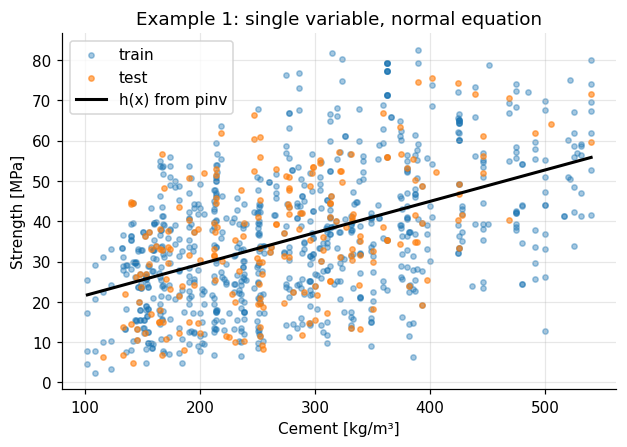

In [7]:
display(record("Ex1 · single var · normal eq.", X_tr_1 @ theta_ne1, X_te_1 @ theta_ne1))

x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.scatter(x_tr_1, y_tr, s=12, alpha=0.4, label="train")
ax.scatter(x_te_1, y_te, s=12, alpha=0.6, label="test")
ax.plot(x_line, add_bias(x_line) @ theta_ne1, color="k", lw=2, label="h(x) from pinv")
ax.set_xlabel("Cement [kg/m³]"); ax.set_ylabel("Strength [MPa]")
ax.set_title("Example 1: single variable, normal equation"); ax.legend()
plt.show()

**Observation.** One feature captures the trend but leaves most of the scatter unexplained: strength also depends on water, age, supplementary binders and more. Example 3 adds them.

---
## 3. Example 2 — Single variable, gradient descent

### The algorithm
Repeat until convergence, updating **all** parameters simultaneously:

$$
\theta_j := \theta_j - \alpha\,\frac{\partial J}{\partial\theta_j}
= \theta_j - \alpha\,\frac1m\sum_{i=1}^m\big(h_{\boldsymbol\theta}(\mathbf x^{(i)})-y^{(i)}\big)x_j^{(i)}
\qquad (j = 0,\dots,n)
$$

Vectorized, the whole update is again one line:

$$
\boldsymbol\theta := \boldsymbol\theta - \frac{\alpha}{m}\,\mathbf X^\top(\mathbf X\boldsymbol\theta-\mathbf y)
$$

### Three practical decisions
1. **Learning rate $\alpha$.** Too small → slow; too large → the cost oscillates or explodes.
2. **Feature scaling.** Cement is in the hundreds while the bias feature is 1, so the cost surface is a long narrow valley. Standardizing $x \leftarrow (x-\mu)/\sigma$, **using training statistics only**, makes the contours round and lets a single $\alpha$ work for every parameter.
3. **Stopping rule.** A fixed number of iterations, or stop when $J$ changes by less than a tolerance.

In [8]:
def gradient_descent(X, y, alpha, n_iters, tol=None):
    m, d = X.shape
    theta = np.zeros(d)                               # initial guess
    J_hist = [compute_cost(X, y, theta)]
    theta_hist = [theta.copy()]
    for it in range(n_iters):
        grad = X.T @ (X @ theta - y) / m              # vectorized gradient ∇J(θ)
        theta = theta - alpha * grad                  # simultaneous update of every θ_j
        J_hist.append(compute_cost(X, y, theta))
        theta_hist.append(theta.copy())
        if not np.isfinite(J_hist[-1]):               # diverged
            break
        if tol is not None and abs(J_hist[-2] - J_hist[-1]) < tol:
            break
    return theta, np.array(J_hist), np.array(theta_hist)

In [9]:
# 1) Feature scaling with TRAINING statistics
mu1, sd1 = x_tr_1.mean(axis=0), x_tr_1.std(axis=0)
X_tr_1s = add_bias((x_tr_1 - mu1) / sd1)
X_te_1s = add_bias((x_te_1 - mu1) / sd1)

# 2) Run gradient descent
alpha = 0.1
theta_gd1, J_gd1, path_gd1 = gradient_descent(X_tr_1s, y_tr, alpha=alpha, n_iters=5000, tol=1e-10)
print(f"Stopped after {len(J_gd1) - 1} iterations, final cost J = {J_gd1[-1]:.4f}")

# 3) Map the scaled parameters back to the original cement units
w1 = theta_gd1[1:] / sd1
b1 = theta_gd1[0] - w1 @ mu1
print(f"GD  (original units): θ0 = {b1:.4f}, θ1 = {w1[0]:.6f}")
print(f"pinv (Example 1)    : θ0 = {theta_ne1[0]:.4f}, θ1 = {theta_ne1[1]:.6f}")

# First iterations, for intuition
first = pd.DataFrame(path_gd1[:6], columns=["θ0 (scaled)", "θ1 (scaled)"])
first["J(θ)"] = J_gd1[:6]
first.index.name = "iteration"
display(first.round(3))

display(record("Ex2 · single var · gradient descent",
               X_tr_1s @ theta_gd1, X_te_1s @ theta_gd1, iterations=len(J_gd1) - 1))

Stopped after 134 iterations, final cost J = 107.0015
GD  (original units): θ0 = 13.7852, θ1 = 0.077896
pinv (Example 1)    : θ0 = 13.7852, θ1 = 0.077896


,θ0 (scaled),θ1 (scaled),J(θ)
iteration,,,
0,0.000,0.000,784.936
1,3.586,0.837,656.129
2,6.813,1.591,551.795
3,9.717,2.269,467.284
4,12.332,2.879,398.830
5,14.684,3.428,343.383


,model,train RMSE,train MAE,train R2,test RMSE,test MAE,test R2,iterations
0,Ex2 · single var · gradient descent,14.629,11.92,0.247,13.885,11.556,0.252,134


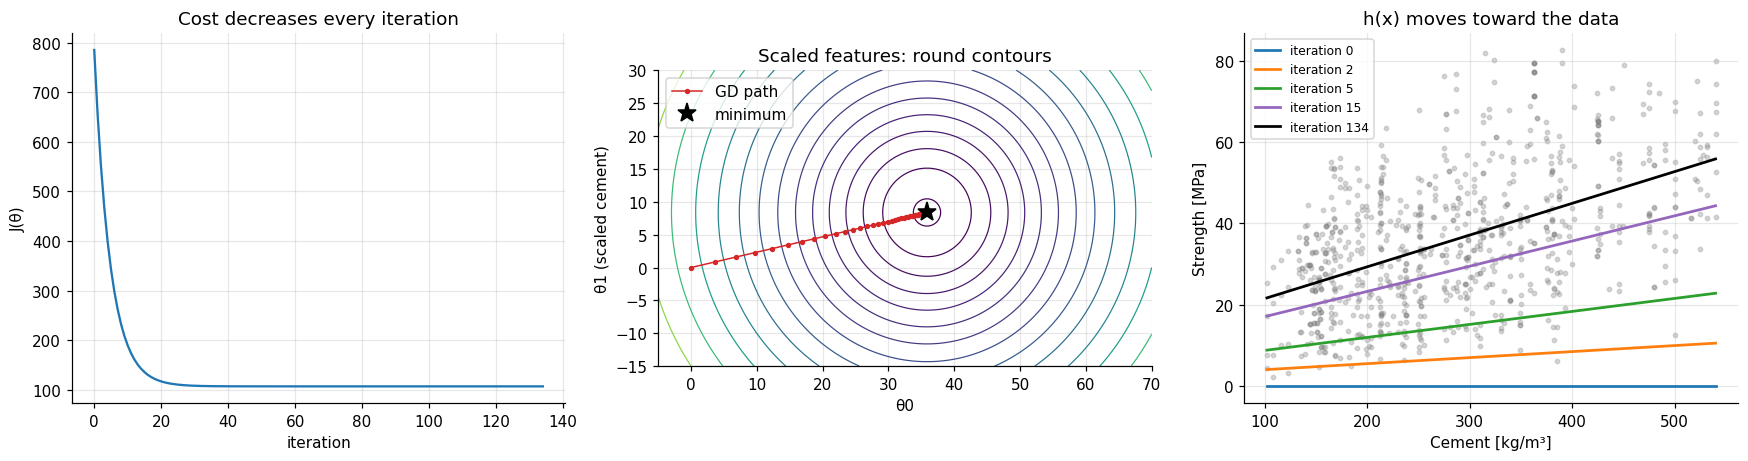

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))

# (a) learning curve
ax[0].plot(J_gd1)
ax[0].set_xlabel("iteration"); ax[0].set_ylabel("J(θ)")
ax[0].set_title("Cost decreases every iteration")

# (b) path on the cost surface (scaled parameters)
t0 = np.linspace(-5, 70, 200); t1 = np.linspace(-15, 30, 200)
T0, T1 = np.meshgrid(t0, t1)
z = X_tr_1s[:, 1]
Jgrid = np.mean((T0[..., None] + T1[..., None] * z - y_tr) ** 2, axis=2) / 2
ax[1].contour(T0, T1, Jgrid, levels=np.geomspace(Jgrid.min() * 1.02, Jgrid.max(), 15),
              cmap="viridis", linewidths=0.8)
ax[1].plot(path_gd1[:, 0], path_gd1[:, 1], "o-", ms=2.5, lw=1, color="C3", label="GD path")
ax[1].plot(*theta_gd1, "k*", ms=13, label="minimum")
ax[1].set_aspect("equal")
ax[1].set_xlabel("θ0"); ax[1].set_ylabel("θ1 (scaled cement)")
ax[1].set_title("Scaled features: round contours"); ax[1].legend(loc="upper left")

# (c) the hypothesis during training
ax[2].scatter(x_tr_1, y_tr, s=8, alpha=0.3, color="gray")
for it, c in zip([0, 2, 5, 15, len(path_gd1) - 1], ["C0", "C1", "C2", "C4", "k"]):
    th = path_gd1[it]
    ax[2].plot(x_line, th[0] + th[1] * (x_line - mu1[0]) / sd1[0], color=c, lw=1.8, label=f"iteration {it}")
ax[2].set_xlabel("Cement [kg/m³]"); ax[2].set_ylabel("Strength [MPa]")
ax[2].set_title("h(x) moves toward the data"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Choosing the learning rate
With one standardized feature, $\frac1m\mathbf X^\top\mathbf X$ is the identity matrix, so every step multiplies the remaining error by $|1-\alpha|$:
- $\alpha<1$: steady decrease (slow when $\alpha$ is small);
- $\alpha=1$: the minimum is reached in **one** step;
- $1<\alpha<2$: overshoots and oscillates, but still converges;
- $\alpha>2$: the error grows every step — **divergence**.

In the plot, $\alpha=0.1$ and $\alpha=1.9$ share the factor $|1-\alpha|=0.9$, so their cost curves lie on top of each other: one approaches the minimum from one side, the other jumps across it on every step.

With more features the limit becomes $\alpha < 2/\lambda_{\max}$, where $\lambda_{\max}$ is the largest eigenvalue of $\frac1m\mathbf X^\top\mathbf X$.

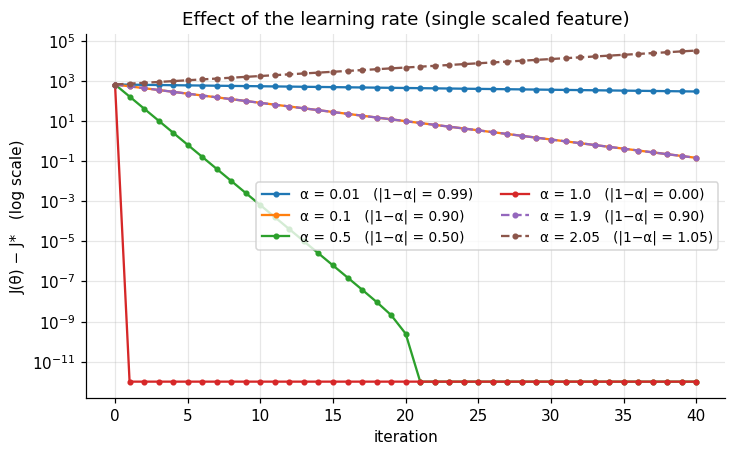

In [11]:
J_star1 = compute_cost(X_tr_1s, y_tr, theta_gd1)
fig, ax = plt.subplots(figsize=(7.5, 4.3))
for a in [0.01, 0.1, 0.5, 1.0, 1.9, 2.05]:
    _, Jh, _ = gradient_descent(X_tr_1s, y_tr, alpha=a, n_iters=40)
    ax.semilogy(np.maximum(Jh - J_star1, 1e-12), marker="o", ms=3,
                ls="--" if a > 1 else "-", label=f"α = {a}   (|1−α| = {abs(1 - a):.2f})")
ax.set_xlabel("iteration"); ax.set_ylabel("J(θ) − J*   (log scale)")
ax.set_title("Effect of the learning rate (single scaled feature)")
ax.legend(ncol=2, fontsize=9)
plt.show()

---
## 4. Example 3 — Multiple variables, normal equation with the pseudo-inverse

Nothing in the math changes: $\mathbf X$ simply has $n+1 = 9$ columns, and the same one line trains the model.

In [12]:
FEATURES = COLS[:-1]
X_tr_m = add_bias(train_df[FEATURES].to_numpy())      # shape (m, 9)
X_te_m = add_bias(test_df[FEATURES].to_numpy())

theta_ne_m = np.linalg.pinv(X_tr_m) @ y_tr            # ← the entire training step

print("X shape:", X_tr_m.shape)
display(pd.Series(theta_ne_m, index=["bias"] + FEATURES, name="θ").round(4).to_frame())
display(record("Ex3 · multi var · normal eq.", X_tr_m @ theta_ne_m, X_te_m @ theta_ne_m))

X shape: (824, 9)


,θ
bias,-28.8236
cement,0.1190
slag,0.1085
fly_ash,0.0822
water,-0.1353
superplasticizer,0.3106
coarse_agg,0.0179
fine_agg,0.0241
age,0.1164


,model,train RMSE,train MAE,train R2,test RMSE,test MAE,test R2
0,Ex3 · multi var · normal eq.,10.519,8.33,0.611,9.796,7.746,0.628


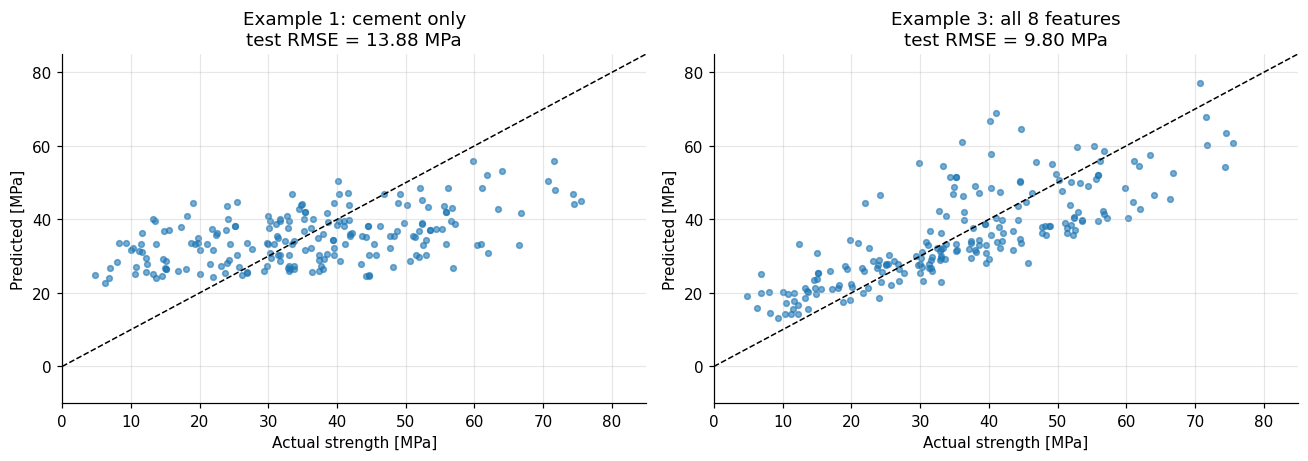

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
for a_, (X_, th_, name) in zip(ax, [(X_te_1, theta_ne1, "Example 1: cement only"),
                                    (X_te_m, theta_ne_m, "Example 3: all 8 features")]):
    p = X_ @ th_
    a_.scatter(y_te, p, s=14, alpha=0.6)
    a_.plot([0, 85], [0, 85], "k--", lw=1)
    a_.set_xlim(0, 85); a_.set_ylim(-10, 85)
    a_.set_xlabel("Actual strength [MPa]"); a_.set_ylabel("Predicted [MPa]")
    a_.set_title(f"{name}\ntest RMSE = {np.sqrt(mean_squared_error(y_te, p)):.2f} MPa")
plt.tight_layout(); plt.show()

### Why the pseudo-inverse is the safe choice: redundant features
Real feature tables often contain redundant columns. We test two cases:

- **(a) an exact duplicate** — the cement column added twice;
- **(b) a derived column** — total binder = cement + slag + fly ash, an exact linear combination of three existing columns.

In both cases $\mathbf X$ is rank-deficient, so $\mathbf X^\top\mathbf X$ is singular and has no inverse. With `inv`, case (a) raises an error, and case (b) may silently return numbers that do **not** solve the normal equation (floating-point round-off hides the singularity). `pinv` treats the zero singular value correctly and returns the minimum-norm least-squares solution, whose predictions equal those of Example 3.

A reliable check is the **normal-equation residual** $\lVert\mathbf X^\top\mathbf X\boldsymbol\theta-\mathbf X^\top\mathbf y\rVert$, which must be (numerically) zero at the true minimum, and the training RMSE, which can never be lower than the least-squares minimum.

In [14]:
def check_redundant(name, extra_tr, extra_te):
    A_tr = np.column_stack([X_tr_m, extra_tr])
    A_te = np.column_stack([X_te_m, extra_te])
    rows = []
    for method in ["inv", "pinv"]:
        try:
            if method == "inv":
                th = np.linalg.inv(A_tr.T @ A_tr) @ A_tr.T @ y_tr
            else:
                th = np.linalg.pinv(A_tr) @ y_tr
            rows.append({"case": name, "method": method,
                         "normal-eq. residual": np.linalg.norm(A_tr.T @ A_tr @ th - A_tr.T @ y_tr),
                         "train RMSE": np.sqrt(mean_squared_error(y_tr, A_tr @ th)),
                         "test RMSE": np.sqrt(mean_squared_error(y_te, A_te @ th))})
        except np.linalg.LinAlgError as err:
            rows.append({"case": name, "method": method, "normal-eq. residual": np.nan,
                         "train RMSE": np.nan, "test RMSE": np.nan, "note": f"LinAlgError: {err}"})
    print(f"{name}: {A_tr.shape[1]} columns, rank {np.linalg.matrix_rank(A_tr)}")
    return rows

rows = []
rows += check_redundant("(a) duplicate cement",
                        train_df["cement"].to_numpy(), test_df["cement"].to_numpy())
rows += check_redundant("(b) total binder",
                        train_df[["cement", "slag", "fly_ash"]].sum(axis=1).to_numpy(),
                        test_df[["cement", "slag", "fly_ash"]].sum(axis=1).to_numpy())

base_train = np.sqrt(mean_squared_error(y_tr, X_tr_m @ theta_ne_m))
print(f"Example 3 (no redundant column): train RMSE = {base_train:.4f}  ← the least-squares minimum")
pd.DataFrame(rows).round(4)

(a) duplicate cement: 10 columns, rank 9
(b) total binder: 10 columns, rank 9
Example 3 (no redundant column): train RMSE = 10.5188  ← the least-squares minimum


,case,method,normal-eq. residual,train RMSE,test RMSE,note
0,(a) duplicate cement,inv,NaN,NaN,NaN,LinAlgError: Singular matrix
1,(a) duplicate cement,pinv,0.000000e+00,10.5188,9.7965,NaN
2,(b) total binder,inv,2.074834e+07,21.9443,20.5578,NaN
3,(b) total binder,pinv,0.000000e+00,10.5188,9.7965,NaN


---
## 5. Example 4 — Multiple variables, gradient descent

The update rule is unchanged. What changes is **conditioning**: the eight raw features range from single digits (superplasticizer) to about 1,000 (coarse aggregate). We first try gradient descent **without** scaling to see why scaling is not optional.

In [15]:
# Largest / smallest eigenvalue of (1/m)·XᵀX controls the usable learning rate and the speed
def curvature(X):
    lam = np.linalg.eigvalsh(X.T @ X / len(X))
    return lam.min(), lam.max()

lmin_raw, lmax_raw = curvature(X_tr_m)
print(f"Raw features : λmax = {lmax_raw:.3e}, λmin = {lmin_raw:.3e}, "
      f"κ = {lmax_raw / lmin_raw:.2e}, stable only if α < {2 / lmax_raw:.2e}")

# (a) a 'normal' learning rate explodes
_, J_bad, _ = gradient_descent(X_tr_m, y_tr, alpha=0.01, n_iters=50)
print(f"α = 0.01, raw features → cost after {len(J_bad) - 1} iterations: {J_bad[-1]:.3e}")

# (b) a stable learning rate crawls
alpha_raw = 1.0 / lmax_raw
theta_raw, J_raw, _ = gradient_descent(X_tr_m, y_tr, alpha=alpha_raw, n_iters=5000)
J_star_m = compute_cost(X_tr_m, y_tr, theta_ne_m)
print(f"α = {alpha_raw:.2e}, raw features → after 5000 iterations J − J* = {J_raw[-1] - J_star_m:.2f}")

Raw features : λmax = 1.672e+06, λmin = 1.578e-04, κ = 1.06e+10, stable only if α < 1.20e-06
α = 0.01, raw features → cost after 36 iterations: inf
α = 5.98e-07, raw features → after 5000 iterations J − J* = 0.88


In [16]:
# Standardize every feature with TRAINING statistics
x_tr_m = train_df[FEATURES].to_numpy()
x_te_m = test_df[FEATURES].to_numpy()
mu_m, sd_m = x_tr_m.mean(axis=0), x_tr_m.std(axis=0)
X_tr_ms = add_bias((x_tr_m - mu_m) / sd_m)
X_te_ms = add_bias((x_te_m - mu_m) / sd_m)

lmin_s, lmax_s = curvature(X_tr_ms)
print(f"Scaled features: λmax = {lmax_s:.3f}, λmin = {lmin_s:.3f}, "
      f"κ = {lmax_s / lmin_s:.1f}, stable if α < {2 / lmax_s:.3f}")

alpha_m = 1.0 / lmax_s
t0 = time.perf_counter()
theta_gd_m, J_gd_m, path_gd_m = gradient_descent(X_tr_ms, y_tr, alpha=alpha_m, n_iters=100_000, tol=1e-10)
t_gd = time.perf_counter() - t0
print(f"α = {alpha_m:.3f}: stopped after {len(J_gd_m) - 1} iterations ({t_gd * 1000:.0f} ms)")

# Back to original units and compare with the pseudo-inverse solution
w_m = theta_gd_m[1:] / sd_m
b_m = theta_gd_m[0] - w_m @ mu_m
display(pd.DataFrame({"GD (scaled → original units)": np.r_[b_m, w_m],
                      "pinv (Example 3)": theta_ne_m},
                     index=["bias"] + FEATURES).round(4))

display(record("Ex4 · multi var · gradient descent",
               X_tr_ms @ theta_gd_m, X_te_ms @ theta_gd_m, iterations=len(J_gd_m) - 1))

Scaled features: λmax = 2.242, λmin = 0.031, κ = 72.2, stable if α < 0.892
α = 0.446: stopped after 729 iterations (41 ms)


,GD (scaled → original units),pinv (Example 3)
bias,-28.8171,-28.8236
cement,0.1190,0.1190
slag,0.1085,0.1085
fly_ash,0.0821,0.0822
water,-0.1353,-0.1353
superplasticizer,0.3106,0.3106
coarse_agg,0.0179,0.0179
fine_agg,0.0241,0.0241
age,0.1164,0.1164


,model,train RMSE,train MAE,train R2,test RMSE,test MAE,test R2,iterations
0,Ex4 · multi var · gradient descent,10.519,8.33,0.611,9.796,7.746,0.628,729


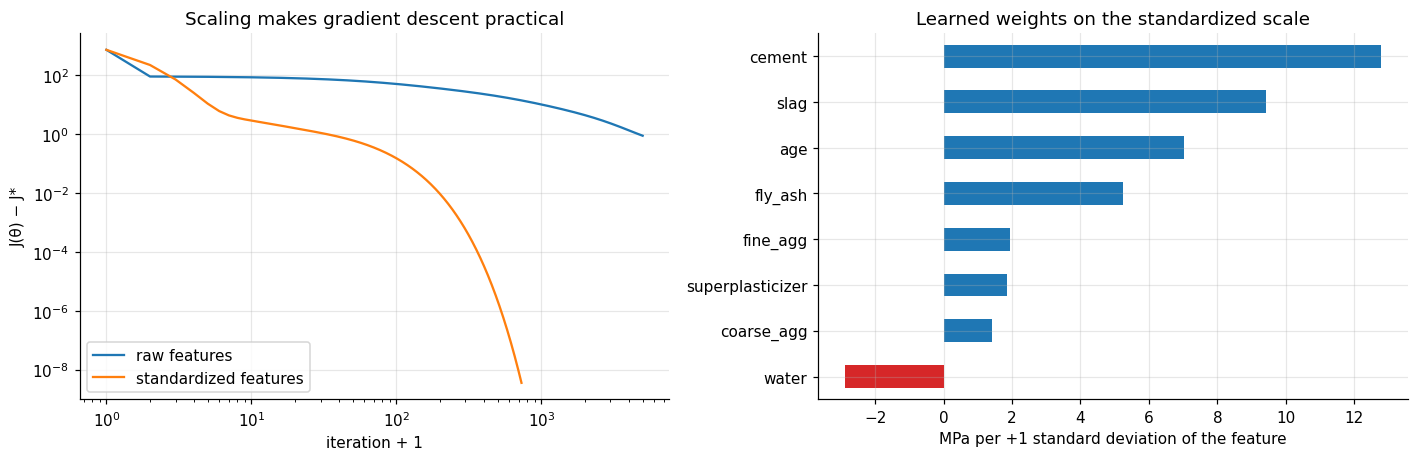

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))

ax[0].loglog(np.arange(1, len(J_raw) + 1), J_raw - J_star_m, label="raw features")
ax[0].loglog(np.arange(1, len(J_gd_m) + 1), np.maximum(J_gd_m - J_star_m, 1e-12), label="standardized features")
ax[0].set_xlabel("iteration + 1"); ax[0].set_ylabel("J(θ) − J*")
ax[0].set_title("Scaling makes gradient descent practical"); ax[0].legend()

weights = pd.Series(theta_gd_m[1:], index=FEATURES).sort_values()
weights.plot.barh(ax=ax[1], color=np.where(weights > 0, "C0", "C3"))
ax[1].set_xlabel("MPa per +1 standard deviation of the feature")
ax[1].set_title("Learned weights on the standardized scale")
plt.tight_layout(); plt.show()

**Reading the weights.** On the standardized scale all features share the same unit (one standard deviation), so the magnitudes can be compared: in this dataset cement and age push strength up, water pulls it down. Weights of correlated features should still be read with care — the model only guarantees good **predictions**, not a causal explanation.

---
## 6. Comparison: which method when?

In [18]:
summary = pd.DataFrame(results).set_index("model")
display(summary[["train RMSE", "test RMSE", "test MAE", "test R2", "iterations"]].round(3))

# Timing on this dataset
t0 = time.perf_counter()
for _ in range(100):
    np.linalg.pinv(X_tr_m) @ y_tr
t_pinv = (time.perf_counter() - t0) / 100
print(f"pinv on this dataset: {t_pinv * 1e3:.2f} ms per fit   |   gradient descent: {t_gd * 1e3:.0f} ms")

,train RMSE,test RMSE,test MAE,test R2,iterations
model,,,,,
Ex1 · single var · normal eq.,14.629,13.885,11.556,0.252,NaN
Ex2 · single var · gradient descent,14.629,13.885,11.556,0.252,134.0
Ex3 · multi var · normal eq.,10.519,9.796,7.746,0.628,NaN
Ex4 · multi var · gradient descent,10.519,9.796,7.746,0.628,729.0


pinv on this dataset: 1.46 ms per fit   |   gradient descent: 41 ms


,pinv [s],"GD, 50 iterations [s]"
n features,,
50,0.084,0.044
200,0.280,0.416
800,6.430,0.766
1600,20.102,0.593
2400,24.418,1.149


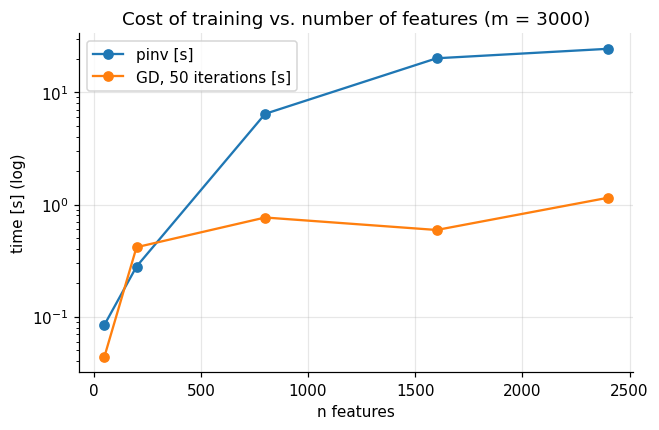

In [24]:
# How do the two methods scale with the number of features n?
rng = np.random.default_rng(SEED)
m_syn, rows = 3000, []
for n_feat in [50, 200, 800, 1600, 2400]:
    Xs = add_bias(rng.standard_normal((m_syn, n_feat)))
    ys = Xs @ rng.standard_normal(n_feat + 1) + rng.standard_normal(m_syn)
    t0 = time.perf_counter(); np.linalg.pinv(Xs) @ ys; tp = time.perf_counter() - t0
    t0 = time.perf_counter(); gradient_descent(Xs, ys, alpha=0.5, n_iters=50); tg = time.perf_counter() - t0
    rows.append({"n features": n_feat, "pinv [s]": tp, "GD, 50 iterations [s]": tg})
timing = pd.DataFrame(rows).set_index("n features")
display(timing.round(3))

ax = timing.plot(marker="o", logy=True, figsize=(6.5, 4))
ax.set_ylabel("time [s] (log)"); ax.set_title(f"Cost of training vs. number of features (m = {m_syn})")
plt.show()

| | **Normal equation (`pinv`)** | **Gradient descent** |
|---|---|---|
| Hyper-parameters | none | learning rate, iterations, stopping rule |
| Feature scaling | not needed (predictions unchanged) | essential |
| Result | exact minimum in one step | approximate, improves with iterations |
| Cost | SVD: about $O(mn^2)$, grows quickly with $n$ | $O(mn)$ per iteration |
| Memory | whole $\mathbf X$ at once | can work on mini-batches (streaming, huge $m$) |
| Other models | only for linear least squares | works for any differentiable cost — logistic regression, neural networks |

**Rule of thumb.** For linear regression with up to a few thousand features, use the one-line pseudo-inverse. Learn gradient descent anyway: from Week 4 onward (classification, neural networks) there is no closed-form solution, and gradient descent is how every model is trained.

---
## 7. Exercises

=== 특성별 단일 회귀 모델 성능 순위 (Test RMSE 기준) ===


,Feature (특성명),Train RMSE (훈련 오차),Test RMSE (테스트 오차),θ0 (절편),θ1 (기울기)
0,cement,14.629,13.885,13.7852,0.0779
4,superplasticizer,15.768,14.590,29.7031,0.9985
3,water,16.158,15.259,76.7811,-0.2251
7,age,15.898,15.263,31.7219,0.0926
6,fine_agg,16.642,15.727,61.3312,-0.0330
5,coarse_agg,16.605,15.916,71.6633,-0.0368
1,slag,16.651,16.134,33.6204,0.0301
2,fly_ash,16.665,16.446,37.9556,-0.0395



 가장 예측력이 뛰어난 단일 특성: 'cement' (Test RMSE: 13.885)


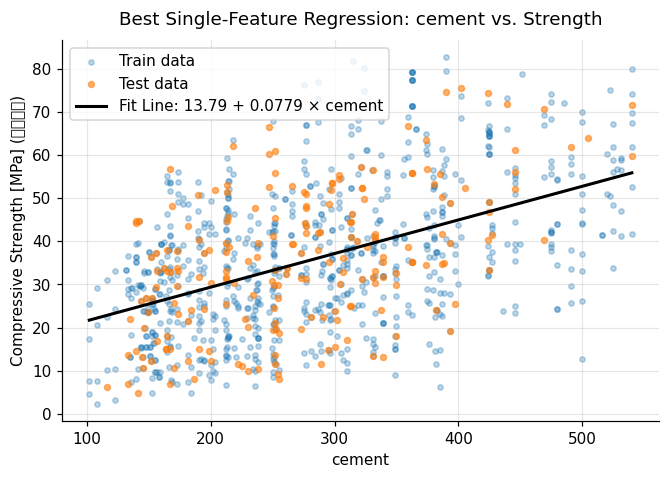

In [27]:
# ✏️ Exercise 1 — Which single feature is most predictive?
# TODO 1: For each of the 8 features, train a single-variable model with the one-line pinv solution.
# TODO 2: Collect train and test RMSE in a DataFrame and sort by test RMSE.
# TODO 3: Plot the best feature with its regression line. Is the answer what you expected from concrete technology?

# 8개 입력 특성 각각으로 단일 변수 모델을 학습하고 RMSE 평가 결과를 수집.
ex1_results = []

for feature_name in FEATURES:
    # 1. 특성 데이터 추출 및 2차원 배열 형태로 변환 (m, 1)
    x_tr = train_df[[feature_name]].to_numpy()
    x_te = test_df[[feature_name]].to_numpy()

    # 2. 절편(Bias)을 위한 1로 채워진 첫 번째 열 추가 [1, x] (m, 2)
    X_tr = add_bias(x_tr)
    X_te = add_bias(x_te)

    # 3. 의사역행렬(pinv)을 사용한 한 줄 학습: θ = (X⁺) * y
    theta = np.linalg.pinv(X_tr) @ y_tr

    # 4. 훈련 데이터 및 테스트 데이터 예측값 계산
    y_pred_tr = X_tr @ theta
    y_pred_te = X_te @ theta

    # 5. RMSE(평균 제곱근 오차) 계산
    train_rmse = np.sqrt(mean_squared_error(y_tr, y_pred_tr))
    test_rmse = np.sqrt(mean_squared_error(y_te, y_pred_te))

    # 6. 결과를 리스트에 저장
    ex1_results.append(
        {
            "Feature (특성명)": feature_name,
            "Train RMSE (훈련 오차)": round(train_rmse, 3),
            "Test RMSE (테스트 오차)": round(test_rmse, 3),
            "θ0 (절편)": round(theta[0], 4),
            "θ1 (기울기)": round(theta[1], 4),
        }
    )

# 테스트 RMSE(낮을수록 예측 성능이 좋음) 기준으로 내림차순 정렬하여 표 출력
df_ex1 = pd.DataFrame(ex1_results).sort_values("Test RMSE (테스트 오차)")
print("=== 특성별 단일 회귀 모델 성능 순위 (Test RMSE 기준) ===")
display(df_ex1)


# TODO 3: 가장 성능이 뛰어난(Test RMSE가 가장 낮은) 특성을 선정하고 회귀선 시각화
best_feature = df_ex1.iloc[0]["Feature (특성명)"]
print(
    f"\n 가장 예측력이 뛰어난 단일 특성: '{best_feature}' (Test RMSE: {df_ex1.iloc[0]['Test RMSE (테스트 오차)']})"
)

# 최고 성능 특성 데이터 준비
x_best_tr = train_df[[best_feature]].to_numpy()
x_best_te = test_df[[best_feature]].to_numpy()
X_best_tr = add_bias(x_best_tr)
theta_best = np.linalg.pinv(X_best_tr) @ y_tr

# 시각화를 위한 직선 x 좌표 생성
x_line = np.linspace(df[best_feature].min(), df[best_feature].max(), 100)
X_line = add_bias(x_line.reshape(-1, 1))
y_line = X_line @ theta_best

# 그래프 그리기
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(
    x_best_tr, y_tr, s=12, alpha=0.3, color="C0", label="Train data"
)
ax.scatter(
    x_best_te, y_te, s=15, alpha=0.6, color="C1", label="Test data"
)
ax.plot(
    x_line,
    y_line,
    color="black",
    linewidth=2,
    label=f"Fit Line: {theta_best[0]:.2f} + {theta_best[1]:.4f} × {best_feature}",
)

ax.set_xlabel(f"{best_feature}")
ax.set_ylabel("Compressive Strength [MPa] (압축강도)")
ax.set_title(
    f"Best Single-Feature Regression: {best_feature} vs. Strength",
    fontsize=12,
    pad=10,
)
ax.legend()
plt.show()

,model,train RMSE,train MAE,train R2,test RMSE,test MAE,test R2,epochs,batch_size
0,Ex2-MBGD · mini-batch GD,10.537,8.377,0.609,9.841,7.834,0.624,50,32


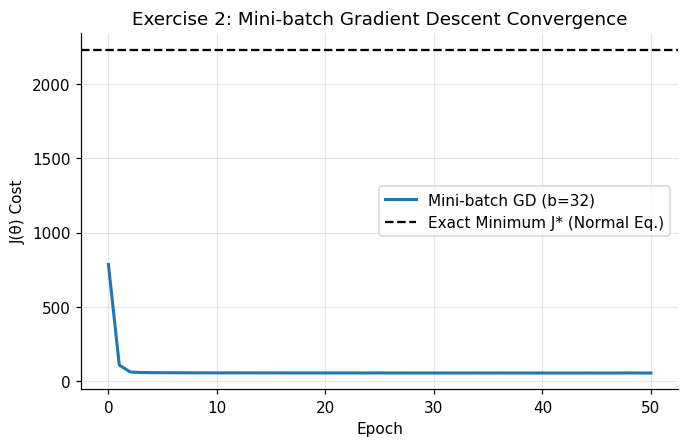

Mini-batch GD 최종 Test RMSE : 9.841
Example 4 (Batch GD) Test RMSE: 9.796


In [29]:
# ✏️ Exercise 2 — Mini-batch gradient descent
# TODO 1: Write minibatch_gd(X, y, alpha, batch_size, n_epochs, seed) that shuffles the rows each epoch
#         and updates θ with the gradient of each mini-batch.
# TODO 2: Train on X_tr_ms with batch_size = 32, alpha = 0.05, n_epochs = 50.
# TODO 3: Plot the full training cost after each epoch and compare the test RMSE with Example 4.
#         Why does the cost keep fluctuating slightly instead of settling exactly at J*?

# 에포크(epoch)마다 행을 섞고 미니배치 단위로 θ를 업데이트하는 함수 제작
def minibatch_gd(X, y, alpha, batch_size, n_epochs, seed=SEED):
    """Mini-batch Gradient Descent 최적화 함수

    - X: 디자인 행렬 (m, d)
    - y: 타겟 벡터 (m,)
    - alpha: 학습률 (Learning rate)
    - batch_size: 배치 크기
    - n_epochs: 전체 데이터를 순회할 에포크 수
    """
    m, d = X.shape
    theta = np.zeros(d)  # 초깃값 0 설정
    rng = np.random.default_rng(seed)

    # 전체 데이터셋 기준 초기 Cost 기록
    J_hist = [compute_cost(X, y, theta)]

    for epoch in range(n_epochs):
        # 매 에포크마다 데이터 순서를 무작위로 셔플(Shuffle)
        indices = rng.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        # 미니배치 단위로 분할하여 반복 학습
        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i : i + batch_size]
            y_batch = y_shuffled[i : i + batch_size]
            b_size = len(y_batch)

            # 미니배치에 대한 그래디언트 계산: ∇J = (1/b) * X_batchᵀ * (X_batch*θ - y_batch)
            grad = X_batch.T @ (X_batch @ theta - y_batch) / b_size

            # 파라미터 업데이트
            theta = theta - alpha * grad

        # 1 에포크가 끝난 후 "전체 데이터셋" 기준 Cost 기록
        J_hist.append(compute_cost(X, y, theta))

    return theta, np.array(J_hist)


# 표준화된 다중 특성(X_tr_ms)으로 모델 학습
# (batch_size = 32, alpha = 0.05, n_epochs = 50)
batch_size = 32
alpha_mb = 0.05
n_epochs = 50

theta_mb, J_mb = minibatch_gd(
    X_tr_ms, y_tr, alpha=alpha_mb, batch_size=batch_size, n_epochs=n_epochs
)

# 예측 및 성능 평가 (Example 4 배치 GD와 비교를 위해 기록)
y_tr_pred_mb = X_tr_ms @ theta_mb
y_te_pred_mb = X_te_ms @ theta_mb

display(
    record(
        "Ex2-MBGD · mini-batch GD",
        y_tr_pred_mb,
        y_te_pred_mb,
        epochs=n_epochs,
        batch_size=batch_size,
    )
)


# 에포크별 전체 훈련 비용(Cost) 플롯 및 Example 4(Batch GD)와 성능 비교
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(range(len(J_mb)), J_mb, color="C0", lw=2, label="Mini-batch GD (b=32)")

# Example 4(Batch GD)의 최저 Cost 레벨을 점선으로 표시
J_star = compute_cost(X_tr_ms, y_tr, theta_ne_m)
ax.axhline(
    J_star,
    color="black",
    ls="--",
    lw=1.5,
    label="Exact Minimum J* (Normal Eq.)",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("J(θ) Cost")
ax.set_title("Exercise 2: Mini-batch Gradient Descent Convergence")
ax.legend()
plt.show()

print(f"Mini-batch GD 최종 Test RMSE : {scores(y_te, y_te_pred_mb)['RMSE']:.3f}")
print(f"Example 4 (Batch GD) Test RMSE: {results[3]['test RMSE']:.3f}")

In [31]:
# ✏️ Exercise 3 — Feature engineering
# Linear regression is linear in θ, not necessarily in the raw inputs.
# TODO 1: Add two engineered features: log_age = ln(age) and w_b = water / (cement + slag + fly_ash).
# TODO 2: Train with the one-line pinv AND with gradient descent (remember to scale).
# TODO 3: Add both models to the comparison and explain the change in test RMSE.

# TODO 1: 공학적 지식을 반영한 2개의 변형 특성 추가
# 1. log_age = ln(age) : 재령(양생 일수)에 따른 비선형 강도 증가 반영
# 2. w_b = water / (cement + slag + fly_ash) : 물-결합재 비(Abrams' law)

def add_engineered_features(df_input):
    df_new = df_input.copy()
    # 재령의 자연로그 취하기
    df_new["log_age"] = np.log(df_new["age"])
    # 전체 결합재(시멘트 + 슬래그 + 플라이애시) 대비 물의 비율
    binder = df_new["cement"] + df_new["slag"] + df_new["fly_ash"]
    df_new["w_b"] = df_new["water"] / binder
    return df_new


# 훈련 데이터 및 테스트 데이터에 특성 공학 적용
train_df_eng = add_engineered_features(train_df)
test_df_eng = add_engineered_features(test_df)

ENGINEERED_FEATURES = FEATURES + ["log_age", "w_b"]
print(f"새로 구성된 특성 목록 ({len(ENGINEERED_FEATURES)}개):", ENGINEERED_FEATURES)

# TODO 2
# 1: 한 줄 의사역행렬(pinv) 정규 방정식 학습
X_tr_eng = add_bias(train_df_eng[ENGINEERED_FEATURES].to_numpy())
X_te_eng = add_bias(test_df_eng[ENGINEERED_FEATURES].to_numpy())

# pinv 학습 실행
theta_pinv_eng = np.linalg.pinv(X_tr_eng) @ y_tr

y_tr_pred_pinv = X_tr_eng @ theta_pinv_eng
y_te_pred_pinv = X_te_eng @ theta_pinv_eng

display(
    record(
        "Ex3-Eng · normal eq. (pinv)",
        y_tr_pred_pinv,
        y_te_pred_pinv,
        n_features=len(ENGINEERED_FEATURES),
    )
)

# TODO 2
# 2: 경사하강법(Gradient Descent) 학습 (표준화 수행)
x_tr_eng_raw = train_df_eng[ENGINEERED_FEATURES].to_numpy()
x_te_eng_raw = test_df_eng[ENGINEERED_FEATURES].to_numpy()

# 훈련 데이터 통계량(평균, 표준편차)만 사용하여 표준화 하여 Data Leakage 방지)
mu_eng, sd_eng = x_tr_eng_raw.mean(axis=0), x_tr_eng_raw.std(axis=0)
X_tr_eng_s = add_bias((x_tr_eng_raw - mu_eng) / sd_eng)
X_te_eng_s = add_bias((x_te_eng_raw - mu_eng) / sd_eng)

# 곡률 기반 스케일링된 학습률 계산
_, lmax_eng_s = curvature(X_tr_eng_s)
alpha_eng = 1.0 / lmax_eng_s

# 경사하강법 실행
theta_gd_eng, J_gd_eng, _ = gradient_descent(
    X_tr_eng_s, y_tr, alpha=alpha_eng, n_iters=100_000, tol=1e-10
)

y_tr_pred_gd = X_tr_eng_s @ theta_gd_eng
y_te_pred_gd = X_te_eng_s @ theta_gd_eng

display(
    record(
        "Ex3-Eng · gradient descent",
        y_tr_pred_gd,
        y_te_pred_gd,
        n_features=len(ENGINEERED_FEATURES),
        iterations=len(J_gd_eng) - 1,
    )
)

# TODO 3: 기존 다중 회귀(Example 3)와 성능 비교 및 Test RMSE 변화 원인 설명
print("\n=== 기존 8개 특성 모델 vs. 특성 공학 추가 모델 (Test RMSE 비교) ===")
ex3_base_test_rmse = results[2]["test RMSE"]
ex3_eng_test_rmse = scores(y_te, y_te_pred_pinv)["RMSE"]

print(f"- 기존 8개 특성 모델 (Example 3)  Test RMSE : {ex3_base_test_rmse:.3f} MPa")
print(
    f"- 특성 공학 추가 모델 (Exercise 3) Test RMSE : {ex3_eng_test_rmse:.3f} MPa"
)
print(
    f"- 오차 감소폭 (성능 개선)                 : {ex3_base_test_rmse - ex3_eng_test_rmse:.3f} MPa"
)

새로 구성된 특성 목록 (10개): ['cement', 'slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_agg', 'fine_agg', 'age', 'log_age', 'w_b']


,model,train RMSE,train MAE,train R2,test RMSE,test MAE,test R2,n_features
0,Ex3-Eng · normal eq. (pinv),7.023,5.482,0.826,6.57,5.244,0.832,10


,model,train RMSE,train MAE,train R2,test RMSE,test MAE,test R2,n_features,iterations
0,Ex3-Eng · gradient descent,7.023,5.482,0.826,6.57,5.244,0.832,10,1733



=== 기존 8개 특성 모델 vs. 특성 공학 추가 모델 (Test RMSE 비교) ===
- 기존 8개 특성 모델 (Example 3)  Test RMSE : 9.796 MPa
- 특성 공학 추가 모델 (Exercise 3) Test RMSE : 6.570 MPa
- 오차 감소폭 (성능 개선)                 : 3.226 MPa


=== 다항식 차수(d)별 성능 변화 ===


,d (차수),Train RMSE,Test RMSE,cond(Z)
0,1,14.020,13.526,1.0
1,2,13.939,13.366,2.5
2,3,13.751,13.260,7.3
3,4,13.710,13.251,15.2
4,5,13.679,13.260,56.7
5,6,13.578,13.202,173.6
6,7,13.503,13.172,1005.2
7,8,13.448,12.992,3645.0
8,9,13.447,13.009,22095.8
9,10,13.447,13.011,666771.8


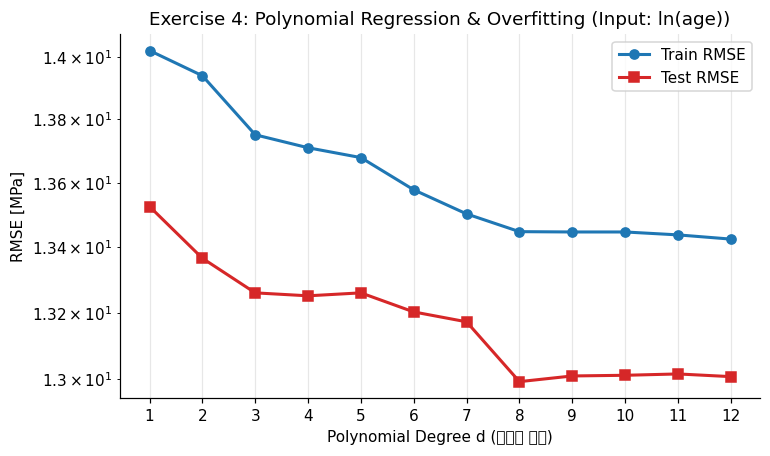

 최적의 다항식 차수: d = 8


In [32]:
# ✏️ Exercise 4 — Polynomial features and overfitting
# TODO 1: Using ONLY age as input, build polynomial features z, z², ..., z^d with z = standardized ln(age)
#         for d = 1 ... 12.
# TODO 2: Fit each model with the one-line pinv and record train and test RMSE.
# TODO 3: Plot both curves against d. Where does the model start to overfit?
#         Why does pinv still return a solution even when the polynomial columns are highly correlated?

# TODO 1: age 변수만 선택 후 표준화된 ln(age) 기반 다항식 특성 생성 (d = 1 ... 12)
# z = standardized ln(age)
ln_age_tr = np.log(train_df[["age"]].to_numpy())
ln_age_te = np.log(test_df[["age"]].to_numpy())

# 훈련 데이터 기준으로 z 스케일링 (Data Leakage 방지)
mu_z, sd_z = ln_age_tr.mean(), ln_age_tr.std()
z_tr = (ln_age_tr - mu_z) / sd_z
z_te = (ln_age_te - mu_z) / sd_z

poly_results = []

# TODO 2: 차수 d = 1부터 12까지 증가시키며 pinv로 적합 및 train/test RMSE 기록
for d in range(1, 13):
    # 다항식 행렬 [z, z², ..., zᵈ] 생성
    Z_tr_raw = np.column_stack([z_tr**i for i in range(1, d + 1)])
    Z_te_raw = np.column_stack([z_te**i for i in range(1, d + 1)])

    # 절편(x0 = 1) 추가 -> 디자인 행렬 (m, d + 1)
    Z_tr = add_bias(Z_tr_raw)
    Z_te = add_bias(Z_te_raw)

    # 한 줄 pinv 정규 방정식 학습
    theta_poly = np.linalg.pinv(Z_tr) @ y_tr

    # 예측값 계산
    y_tr_pred_p = Z_tr @ theta_poly
    y_te_pred_p = Z_te @ theta_poly

    # RMSE 계산
    tr_rmse = np.sqrt(mean_squared_error(y_tr, y_tr_pred_p))
    te_rmse = np.sqrt(mean_squared_error(y_te, y_te_pred_p))

    poly_results.append(
        {
            "d (차수)": d,
            "Train RMSE": round(tr_rmse, 3),
            "Test RMSE": round(te_rmse, 3),
            "cond(Z)": round(np.linalg.cond(Z_tr), 1),  # 조건수 (다중공선성 진단)
        }
    )

df_poly = pd.DataFrame(poly_results)
print("=== 다항식 차수(d)별 성능 변화 ===")
display(df_poly)


# TODO 3: 차수 d에 따른 Train/Test RMSE 곡선 시각화 및 과적합(Overfitting) 발생 지점 확인
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.plot(
    df_poly["d (차수)"],
    df_poly["Train RMSE"],
    "o-",
    color="C0",
    lw=2,
    label="Train RMSE",
)
ax.plot(
    df_poly["d (차수)"],
    df_poly["Test RMSE"],
    "s-",
    color="C3",
    lw=2,
    label="Test RMSE",
)

ax.set_xlabel("Polynomial Degree d (다항식 차수)")
ax.set_ylabel("RMSE [MPa]")
ax.set_title("Exercise 4: Polynomial Regression & Overfitting (Input: ln(age))")
ax.set_xticks(range(1, 13))
ax.set_yscale("log")  # 과적합 시 Test RMSE 폭발을 잘 보이게 하기 위한 로그 스케일
ax.legend()
plt.show()


# 가장 적절한 차수(Test RMSE가 가장 낮은 지점) 출력
best_d = df_poly.loc[df_poly["Test RMSE"].idxmin(), "d (차수)"]
print(f" 최적의 다항식 차수: d = {best_d}")

### Reflection questions (answer in 3–5 sentences each)
1. Why is `np.linalg.pinv(X) @ y` preferred over `np.linalg.inv(X.T @ X) @ X.T @ y`? Refer to both cases of the redundant-feature experiment.
2. Feature scaling did not change the predictions of the normal equation but was essential for gradient descent. Explain why.
3. Give two situations in which you would train a linear model with gradient descent even though a closed-form solution exists.
4. Example 3 improved the test error over Example 1. How do you know the improvement is not just overfitting?

### Generative-AI use disclosure (required by the course policy)
If you used a generative-AI tool for this lab, state the tool, the purpose, representative prompts, what you modified, errors you found in its output, and how you verified the output.

*Your disclosure here.*

---
**Dataset.** I.-C. Yeh (1998), "Modeling of strength of high-performance concrete using artificial neural networks," *Cement and Concrete Research*, 28(12), 1797–1808. UCI Machine Learning Repository, Concrete Compressive Strength.

**학번 : 2021144048**

**이름 : 박규호**

Reflection Question

1번 문제
- np.linalg.inv(X.T @ X)는 디자인 행렬 $X$에 다중공선성이나 중복 변수가 존재할 때 수치적으로 매우 불안정해지거나 오류를 발생시킬 수 있다.먼저,완벽한 중복 열(Duplicate column)이 존재하는 경우 $X^T X$가 특이 행렬(Singular Matrix)이 되어 inv는 LinAlgError를 발생시키며 실행에 실패할 수 있다는 단점이 존재한다. 혹은 Total binder와 같은 파생 선형 결합 열이 존재하는 경우, 부동 소수점 오차 때문에 inv가 에러 없이 작동하더라도 정규 방정식을 만족하지 못하는 엉뚱한 해를 반환할 수 있다는 문제가 존재한다.
- 한편, np.linalg.pinv는 SVD(특이값 분해)를 기반으로 하여 $0$에 가까운 미세한 특이값들을 안정적으로 처리하므로, 두 경우 모두에서 최적의 최소 노름(Minimum-norm) 최소자승해를 항상 정확하게 계산해 낼 수 있다는 장점이 존재하여 더 선호되는 특징이 존재한다.

2번 문제
- normal equation은 $X$ 행렬 전체를 한 번에 연산하여 비용 함수의 전역 최솟값을 Closed-form으로 바로 찾아내기 때문에, 특성의 스케일 변환이 회귀선의 최종 예측 공간을 왜곡하지 않아 스케일링 여부와 상관없이 동일한 예측 결과를 제공할 수 있다는 특징이 존재한다.
- 한편, 경사하강법은 비용 함수 표면의 Gradient를 따라 한 걸음씩 이동하며 최적점을 찾아가는 반복적 알고리즘으로, 특성들의 단위 스케일 차이가 크면 비용 함수의 등고선이 매우 길쭉한 타원형 골짜기 형태가 되어 계수들이 진동하거나 최적 수렴 속도가 극도로 느려지며 심할 경우 발산하게된다. 즉, 특성 스케일링을 적용함으로써 등고선이 동심원 모양으로 형성되도록 도와주고 이를 통해 단일 학습률로도 모든 파라미터가 안정적이고 빠르게 최적점으로 수렴할 수 있게 된다. 따라서, 경사하강법에서는 Feature Scaling은 필수적으로 활용되어야 한다.

3번 문제
- Closed form Solution이 존재하는 상황에서도 경사하강법을 활용해 선형 모델을 학습되어야하는 첫 번째 예시의 경우, 먼저 특성의 개수($n$)가 수십만~수백만 개 이상으로 많은 거대 데이터셋 환경을 예로 들 수 있다. 이 경우, normal equation이나 SVD 계산 비용은 약 $O(n^3)$ 또는 $O(n^2)$와 같은 연산 복잡도를 요구하므로 $n$이 커지면 메모리와 연산 시간 측면에서 불가능해지지만, 경사하강법은 반복당 $O(n)$으로 훨씬 효율적인 방식으므로 특성의 개수가 많은 데이터셋 환경에 적합하다.
- 둘째, 데이터셋 전체를 한 번에 메모리에 올릴 수 없거나 실시간으로 데이터가 입력되는 Streaming 혹은 Online Learning 환경을 예시로 들 수 있다. 이 경우 전체 $X$ 행렬을 구성해야 하는 normal equation은 사용할 수 없다. 따라서 해당 경우에는 Mini-batch 또는 SGD 방식의 경사하강법을 활용할 경우, 메모리 한계를 극복하고 모델을 학습시킬 수 있다.

4번 문제
- 만약 모델이 Overfitting 되었다면, 학습에 활용된 Train data에서의 RMSE는 줄어들지만 학습에 활용하지 않았던 Test data에서의 오차는 증가하거나 악화되는 현상이 나타나야한다. 그러나 Example 3에서는 훈련 데이터 RMSE뿐만 아니라 모델 학습 중에 활용되지 않았던 Held-out Test Data의 RMSE도 유의미하게 감소한 것을 확인할 수 있다. 또한, $R^2$ 점수 역시 상승한 것도 확인할 수 있으며 이를 통해, 학습 과정에 활용되지 않은 새로운 데이터셋에 대해서도 성능이 향상된 것을 확인할 수 있다. 즉, 이러한 Test Data에 대해서도 유지되는 성능 개선을 통해 단순한 Overfitting 이 아니라 실제로 모델의 예측 능력이 개선된 것임을 확인할 수 있다.    

**Generative-AI Use Disclosure**
- Tool used : Gemini
- Purpose : Exercise 문제 1~4 코드 구현 보조 및 추가 문항 답변에 대한 검증
- Representative prompts : 앞선 코드들이 지금 내 환경에서 돌아가나? 이 함수는 어떠한 함수이고 어떤 역할을 수행하지?, Exercise 1~4를 구현하는 과정에서 필요한 배경지식을 이야기해주고 초안을 작성해줘.
- What you modified : AI가 작성한 코드의 변수명 및 시각화 스타일을 실습 노트 원본 형식에 맞춰 통일하였으며, 깨지는 글자를 수정함. 이후, 경사하강법 함수의 에포크별 비용 수렴 그래프 축 단위를 올바르게 재설정.
- How you verified the output : 각 Exercise 셀을 직접 실행해보고 결과로 나타난 반환된 RMSE 값 및 $R^2$ 지표가 원본에서의 수치와 동일한지를 확인.